# NeuroWorkflow: optimizing a single point neuron

Same graph as `NW_SingleCell_PointNeuron.ipynb` — `NW_IClamp → NW_Population → NW_SimConfig → NW_Analysis` —
but an optimizer drives the re-runs instead of editing values by hand.

```
ask → configure → workflow.execute() → read firing rate → fitness → tell
```

The workflow is the objective function. It is built **once** and reconfigured between trials,
exactly like the manual re-run cells in the original notebook.

**Naming.** Each node's variable is given the same word as its instance name — `clamp = NW_IClamp("clamp")` —
because that is what code generation emits (`var_name = instance_name`). One word then serves as the
variable, the instance name, and the prefix of every address.

In [1]:
import os
import sys

# Prefer this repository's sources over any previously installed copy:
# neuroworkflow.optimization is new and an older install would not have it.
sys.path.insert(0, os.path.abspath('../src'))

from neuroworkflow import WorkflowBuilder
from neuroworkflow.nodes.network.NW_Population    import NW_Population
from neuroworkflow.nodes.simulation.NW_SimConfig  import NW_SimConfig
from neuroworkflow.nodes.analysis.NW_Analysis     import NW_Analysis
from neuroworkflow.nodes.stimulus.NW_IClamp       import NW_IClamp

from neuroworkflow.optimization import AlgorithmConfig, build_spec, optimize

## 1. Create the nodes

The string passed to the constructor is the node's **instance name**. Keep the variable identical
to it: that is what the generated code does, and it means an address like `exc.nest_params.V_th`
reads the same whether you are looking at the notebook or at a generated script.

In [2]:
clamp = NW_IClamp("clamp")
exc   = NW_Population("exc")
sim   = NW_SimConfig("sim")
ana   = NW_Analysis("ana")

## 2. Configure each node

Same values as the single-cell notebook, with one addition: `I_e` is included in `nest_params`.
It is not in the node's declared default, but tunable keys are read from the node's **live**
value, so configuring it here is enough to make it optimizable later.

In [3]:
exc.configure(
    pop_name       = "v1",
    N              = 1,
    model_type     = "point_neuron",
    model_template = "nest:iaf_psc_alpha",
    ei_type        = "exc",
    location       = "VISp",
    layer          = "L4",
    nest_params = {
        "C_m":     250.0,   # pF
        "tau_m":   10.0,    # ms
        "t_ref":   2.0,     # ms
        "V_th":    -55.0,   # mV
        "V_reset": -70.0,   # mV
        "E_L":     -70.0,   # mV
        "I_e":     0.0,     # pA  <- added here, not in the node's default dict
    },
)

In [4]:
clamp.configure(amp_na=0.150, delay_ms=500.0, duration_ms=2000.0)

In [5]:
sim.configure(
    simulator   = "pointnet",
    config_file = "config_opt.json",
    tstop_ms    = 3000.0,
    dt_ms       = 0.1,
    reports = {
        "v_report": {
            "variable_name": "V_m",
            "cells":         "all",
            "module":        "membrane_report",
            "sections":      "soma",
        }
    },
)

## 3. Build the workflow

Built once. Every optimization trial reconfigures and re-executes this same object — it is
never rebuilt, the same pattern as the manual re-run cells in the original notebook.

In [6]:
wf = WorkflowBuilder("NW_SingleCell_Optimization")
for node in [clamp, exc, sim, ana]:
    wf.add_node(node)

wf.connect("clamp", "iclamp",     "exc", "iclamp")
wf.connect("exc",   "population", "sim", "populations")
wf.connect("sim",   "results",    "ana", "results")

wf.context["results_path"] = "./results/opt_singlecell"

workflow = wf.build()
print("nodes:", list(workflow.nodes))

nodes: ['clamp', 'exc', 'sim', 'ana']


## 4. Where an address comes from

The optimizer refers to everything by dotted address, and both kinds start with the **node's
instance name**:

| kind | shape | example |
|---|---|---|
| what to tune | `node.parameter[.key]` | `exc.nest_params.V_th` |
| what to measure | `node.output_port[.key]` | `ana.firing_rate_hz.v1` |

Reading `ana.firing_rate_hz.v1` piece by piece:

- `ana` — the **instance name**, from `NW_Analysis("ana")`, readable as `ana.name`.
- `firing_rate_hz` — an **output port** of that node.
- `v1` — a **key inside that port's dict**. It is the population name, so it comes from
  `exc.configure(pop_name=...)`. Change `pop_name` and this key changes with it.

The cell below prints all three sources, so nothing has to be guessed.

In [7]:
for node in [clamp, exc, sim, ana]:
    print(f"{node.name:<6} outputs: {list(node._output_ports)}")

print("\npop_name =", exc._parameters["pop_name"],
      "  -> the key inside ana.firing_rate_hz")

clamp  outputs: ['iclamp']
exc    outputs: ['population']
sim    outputs: ['results']
ana    outputs: ['figures', 'firing_rate_hz', 'isi_stats']

pop_name = v1   -> the key inside ana.firing_rate_hz


## 5. Declare what to optimize

`optimizable`, `optimization_range`, `unit`, `is_objective`, `objective_range` and `measures`
are **schema** fields, so they are set on the parameter definitions — `configure()` only writes
values. This is the same information the GUI stores per node when you tick *optimizable* or
type a target range in the node panel.

Each node carries its own copy of its definition, so setting these here affects only this node.
The target below overrides whatever `NW_Population.py` declares.

**Handle naming: `<role>_<instance>_<parameter>`.** It cannot collide (parameter names are unique
per node, instance names unique per workflow), it cannot shadow a module or keyword — `nest` would
have shadowed the NEST module — and it stays readable when there are several targets.

In [8]:
# A handle is a reference to the node's own parameter definition, not a copy —
# assigning through it edits that node's schema.

# --- what to explore -------------------------------------------------------
explore_clamp_amp_na = clamp.NODE_DEFINITION.parameters["amp_na"]
explore_clamp_amp_na.optimizable        = True
explore_clamp_amp_na.optimization_range = [0.0, 800.0]      # scalar -> [min, max]
explore_clamp_amp_na.unit               = "nA"

explore_exc_nest_params = exc.NODE_DEFINITION.parameters["nest_params"]
explore_exc_nest_params.optimizable        = True
explore_exc_nest_params.optimization_range = {              # dict -> a range per key
    "I_e":  [0.0, 800.0],     # pA
    "V_th": [-60.0, -45.0],   # mV
}

# --- what to optimize -----------------------------------------------------------
target_exc_mean_firing_rate = exc.NODE_DEFINITION.parameters["mean_firing_rate"]
target_exc_mean_firing_rate.default_value   = 10.0          # the desired value
target_exc_mean_firing_rate.unit            = "Hz"
target_exc_mean_firing_rate.is_objective    = True          # this parameter is a target
target_exc_mean_firing_rate.objective_range = [8.0, 12.0]   # reached inside this band
target_exc_mean_firing_rate.measures        = (
    f"{ana.name}.firing_rate_hz.{exc._parameters['pop_name']}"
)

print("target measures:", target_exc_mean_firing_rate.measures)

target measures: ana.firing_rate_hz.v1


## 6. Build the spec

The algorithm is chosen here. `cmaes` suits this problem: three continuous dimensions, one
objective, and `amp_na` and `I_e` are correlated (both inject current), which CMA-ES models and
random sampling does not. It needs `pip install optuna cmaes` — see the alternatives in the cell.

`build_spec()` runs the workflow once at its current values. That run is the baseline every
result is compared against, and it is what each `measures` address is resolved against — a
target pointing at something that does not exist, or is not a number, is reported here rather
than failing midway through the search.

Executing node: clamp
Executing node: exc
Executing node: sim
[NW_SimConfig] network built in ./results/opt_singlecell/network

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Mar  4 2025 17:27:39

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

2026-09-07 00:21:02,939 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-09-07 00:21:02,947 [INFO] Batch processing nodes for v1/0.


INFO:NestIOUtils:Batch processing nodes for v1/0.


2026-09-07 00:21:02,948 [INFO] Setting up output directory


...

2026-09-07 00:21:02,972 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-09-07 00:21:02,983 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: ana
[NW_Analysis] plot_raster skipped: Could not fine spikes file with node population "v1".


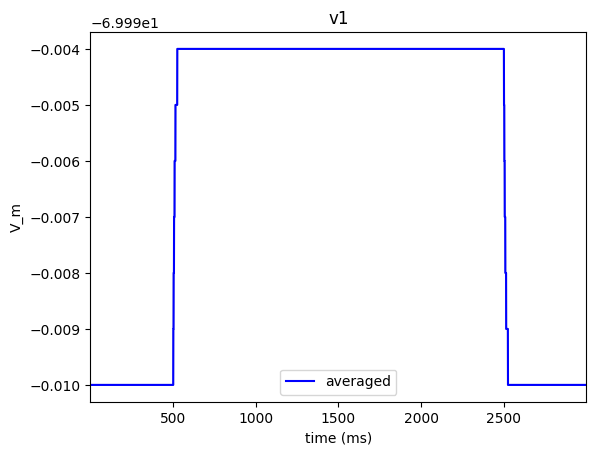

measurable values found in the baseline run:
   ana.firing_rate_hz.v1                         0
   ana.isi_stats.v1.cv                           0
   ana.isi_stats.v1.mean_ms                      0
   ana.isi_stats.v1.n_intervals                  0
   ana.isi_stats.v1.std_ms                       0
   clamp.iclamp.amp                              0.15
   clamp.iclamp.delay                            500
   clamp.iclamp.duration                         2000

algorithm : cmaes (pop_size=6, max_generations=8)
dimensions: 3
    clamp.amp_na                             [0.0, 800.0] nA
    exc.nest_params.I_e                      [0.0, 800.0]
    exc.nest_params.V_th                     [-60.0, -45.0]
objectives: 1
    exc.mean_firing_rate                     in [8.0, 12.0] Hz  <- ana.firing_rate_hz.v1


In [9]:
spec = build_spec(
    workflow,
    algorithm=AlgorithmConfig(name="cmaes", pop_size=6, max_generations=8, seed=1),

    # Other algorithms — same call, one word different:
    #
    #   name="random"  no dependency at all; uniform sampling, useful as a baseline
    #   name="cmaes"   CMA-ES, single objective only; adapts to correlated parameters
    #   name="tpe"     Bayesian; pays off when each trial is expensive
    #   name="nsga2"   2-3 objectives, returns a Pareto front (use pop_size >= 16)
    #   name="nsga3"   more than 3 objectives
    #
    # Everything except "random" needs:  pip install optuna cmaes
    #
    # Sampler-specific settings pass straight through in `options`:
    #   AlgorithmConfig(name="cmaes", pop_size=6, seed=1, options={"sigma0": 0.2})
    #   AlgorithmConfig(name="tpe",   pop_size=6, options={"n_startup_trials": 20})
)

print("measurable values found in the baseline run:")
for address, value in sorted(spec.baseline["measurables"].items()):
    print(f"   {address:<45} {value:g}")

print()
print(spec.summary())

## 7. Run the search

Plotting is switched off first: the firing rate is measured before the plotting blocks in
`analyze()`, so every trial is still measured while no PNGs are written.

Every trial gets its own results directory under the run — this is the default
(`per_trial_results=True`). The `NW_*` nodes rebuild the SONATA network and rewrite `spikes.h5`
on each run, so sharing one directory would lose every trial's output and fail outright while a
handle from the previous trial is still open.

In [10]:
ana.configure(plot_raster=False, plot_traces=False)

result = optimize(
    workflow,
    spec=spec,
    results_path="./results/opt_singlecell/optimization",
)

[opt_20260907_002103] cmaes: 3 dimensions, 1 objective(s), up to 8 generations x 6 candidates
  algorithm : cmaes (pop_size=6, max_generations=8)
  dimensions: 3
      clamp.amp_na                             [0.0, 800.0] nA
      exc.nest_params.I_e                      [0.0, 800.0]
      exc.nest_params.V_th                     [-60.0, -45.0]
  objectives: 1
      exc.mean_firing_rate                     in [8.0, 12.0] Hz  <- ana.firing_rate_hz.v1
  reusing network from ./results/opt_singlecell
Executing node: clamp
Executing node: exc
Executing node: sim
[NW_SimConfig] network unchanged, reusing results/opt_singlecell/optimization/opt_20260907_002103/trials/0001/network
2026-09-07 00:21:03,398 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-09-07 00:21:03,402 [INFO] Batch processing nodes for v1/0.


INFO:NestIOUtils:Batch processing nodes for v1/0.


2026-09-07 00:21:03,404 [INFO] Setting up output directory


...

2026-09-07 00:21:06,007 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-09-07 00:21:06,020 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: ana
  gen 8, trial 6/6 (#48): clamp.amp_na=245.1 nA  exc.nest_params.I_e=429.6  exc.nest_params.V_th=-52.33  ->  mean_firing_rate=52.67 Hz (off 40.67 Hz)
  gen 8/8: best clamp.amp_na=136 nA  exc.nest_params.I_e=323  exc.nest_params.V_th=-52.08  ->  mean_firing_rate=17 Hz [target 8.0-12.0 Hz, off 5 Hz]
[opt_20260907_002103] stopped: generation budget exhausted
  exc.mean_firing_rate = 17 Hz   (target 8.0-12.0 Hz, off 5 Hz)


## 8. Result

`best` is the trial closest to the target band — fitness is a distance, so **smaller is better and
0.0 means inside the band**.

Note the search leaves the workflow holding the **last** trial's parameters, not the best ones —
the loop never writes a result back on its own, because parameters define a run. `apply_best()`
below is the deliberate step that adopts the winner.

In [11]:
print("stop reason:", result.stop_reason)
print("run dir    :", result.run_dir)

if result.best:
    print("\nbest trial:", result.best["trial"])
    for address, value in result.best["params"].items():
        print(f"  {address:<34} {value:.4g}")
    print("  measured:", result.best["measured"])
    print("  distance from target (raw, per objective):", result.best["fitness"])
    print("\nequivalent code:\n")
    print(result.configure_snippet())

stop reason: generation budget exhausted
run dir    : results/opt_singlecell/optimization/opt_20260907_002103

best trial: 28
  clamp.amp_na                       136
  exc.nest_params.I_e                323
  exc.nest_params.V_th               -52.08
  measured: {'exc.mean_firing_rate': 17.0}
  distance from target (raw, per objective): [5.0]

equivalent code:

clamp.configure(amp_na=136.0280981926223)
exc.configure(nest_params={**exc._parameters["nest_params"], "I_e": 323.0420933149711, "V_th": -52.084990627197})


In [12]:
import json

status = json.load(open(os.path.join(result.run_dir, "status.json")))
print("state      :", status["state"], "-", status["stop_reason"])
print("evaluations:", status["n_evals"],
      "| failed:", status["n_failed"],
      "| rejected:", status["n_rejected"])
print("convergence:", status["progress"]["best_target_ranges_off_by_gen"],
      "  (how far the worst objective missed, as a multiple of its target range;"
      " 0 = target met)")

state      : done - generation budget exhausted
evaluations: 48 | failed: 0 | rejected: 0
convergence: [2.583333, 2.583333, 2.0, 2.0, 1.25, 1.25, 1.25, 1.25]   (how far the worst objective missed, as a multiple of its target range; 0 = target met)


## 9. How the search evolved

Three views of the same run:

1. **Measured value per trial** against the target band — did the search get inside it, and when?
2. **Fitness**, the distance from that band. Per-trial points plus the best-so-far curve, which can
   only go down.
3. **Each search dimension** over the run, coloured by fitness. Dark points are good candidates, so a
   dimension whose dark points cluster is one the search has settled; one whose dark points stay
   scattered is a dimension the objective does not really constrain.

Dashed vertical lines mark generation boundaries.


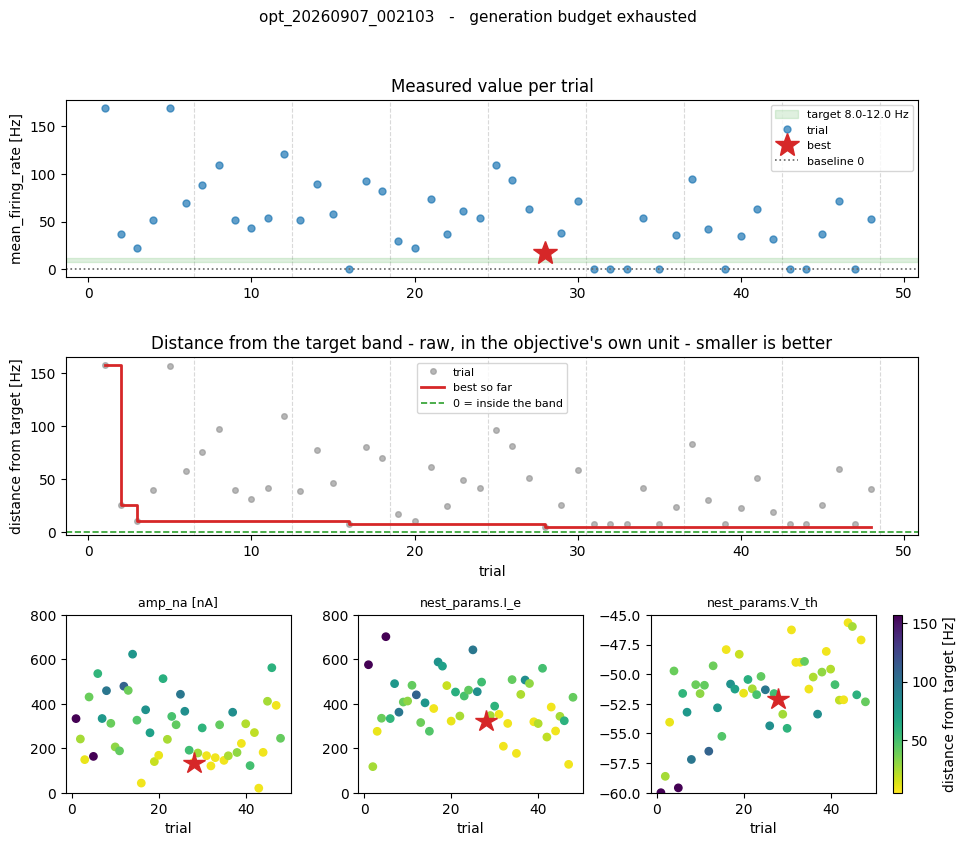

48 scored trials, 0 inside the target band, smallest distance 5 Hz


In [13]:
import matplotlib.pyplot as plt

trials    = result.trials
objective = spec.objectives[0]
scored    = [t for t in trials if t["fitness"] is not None]

if not scored:
    print("no successful trial to plot")
else:
    x        = [t["trial"] for t in scored]
    measured = [t["measured"][objective.name] for t in scored]
    # One objective, so this is simply how far it missed, in its own unit.
    # With several objectives use t["target_ranges_off"] instead: misses in different
    # units cannot be compared until each is sized against its own target range.
    fitness  = [t["fitness"][0] for t in scored]

    best_so_far, running = [], float("inf")
    for value in fitness:
        running = min(running, value)
        best_so_far.append(running)

    best_trial = result.best["trial"]
    pop_size   = spec.algorithm.pop_size
    dims       = spec.dimensions

    fig  = plt.figure(figsize=(11, 9))
    grid = fig.add_gridspec(3, max(len(dims), 1), hspace=0.45, wspace=0.3)
    ax_measured = fig.add_subplot(grid[0, :])
    ax_fitness  = fig.add_subplot(grid[1, :])
    dim_axes    = [fig.add_subplot(grid[2, i]) for i in range(len(dims))]

    def generations(ax):
        for boundary in range(pop_size, max(x) + 1, pop_size):
            ax.axvline(boundary + 0.5, color="0.85", lw=0.8, ls="--", zorder=0)

    # 1 - measured value against the target band
    ax_measured.axhspan(objective.low, objective.high, color="tab:green", alpha=0.15,
                        label=f"target {objective.low}-{objective.high} {objective.unit}")
    generations(ax_measured)
    ax_measured.plot(x, measured, "o", ms=5, color="tab:blue", alpha=0.7, label="trial")
    ax_measured.plot(best_trial, result.best["measured"][objective.name], "*",
                     ms=18, color="tab:red", label="best", zorder=5)
    baseline = spec.baseline.get("measured", {}).get(objective.name)
    if baseline is not None:
        ax_measured.axhline(baseline, color="0.4", ls=":", lw=1.2,
                            label=f"baseline {baseline:.3g}")
    ax_measured.set_ylabel(f"{objective.name.split('.')[-1]} [{objective.unit}]")
    ax_measured.set_title("Measured value per trial")
    ax_measured.legend(fontsize=8, loc="best")

    # 2 - fitness: distance from the band, 0 means inside it
    generations(ax_fitness)
    ax_fitness.plot(x, fitness, "o", ms=4, color="0.6", alpha=0.7, label="trial")
    ax_fitness.step(x, best_so_far, where="post", color="tab:red", lw=2, label="best so far")
    ax_fitness.axhline(0.0, color="tab:green", lw=1.2, ls="--", label="0 = inside the band")
    ax_fitness.set_xlabel("trial")
    ax_fitness.set_ylabel(f"distance from target [{objective.unit}]"
                          if objective.unit else "distance from target")
    ax_fitness.set_title("Distance from the target band - raw, in the objective's "
                         "own unit - smaller is better")
    ax_fitness.legend(fontsize=8, loc="best")

    # 3 - what each dimension was doing, coloured by fitness
    points = None
    for ax, dimension in zip(dim_axes, dims):
        values = [t["params"][dimension.address] for t in scored]
        points = ax.scatter(x, values, c=fitness, cmap="viridis_r", s=28)
        ax.plot(best_trial, result.best["params"][dimension.address], "*",
                ms=16, color="tab:red", zorder=5)
        ax.set_ylim(dimension.low, dimension.high)
        ax.set_xlabel("trial")
        ax.set_title(dimension.address.split(".", 1)[1] +
                     (f" [{dimension.unit}]" if dimension.unit else ""), fontsize=9)
    if points is not None:
        fig.colorbar(points, ax=dim_axes, fraction=0.03, pad=0.02,
                     label=f"distance from target [{objective.unit}]"
                           if objective.unit else "distance from target")

    fig.suptitle(f"{result.run_id}   -   {result.stop_reason}", fontsize=11)
    plt.show()

    inside = [t for t in scored if t["fitness"][0] == 0.0]
    print(f"{len(scored)} scored trials, {len(inside)} inside the target band, "
          f"smallest distance {min(fitness):.4g} {objective.unit}")


## 10. Adopt the winning configuration

`apply_best()` sets the workflow's parameters to the best trial's. With `execute=True` it also
re-runs, so the output ports match the parameters again — without it the ports would still hold
the last trial's values.

In [14]:
result.apply_best(workflow, execute=True)

print("amp_na      =", clamp._parameters["amp_na"])
print("nest_params =", exc._parameters["nest_params"])
print("firing rate =", ana._output_ports["firing_rate_hz"].value)

Executing node: clamp
Executing node: exc
Executing node: sim
[NW_SimConfig] network unchanged, reusing results/opt_singlecell/optimization/opt_20260907_002103/trials/0048/network
2026-09-07 00:21:06,232 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-09-07 00:21:06,236 [INFO] Batch processing nodes for v1/0.


INFO:NestIOUtils:Batch processing nodes for v1/0.


2026-09-07 00:21:06,237 [INFO] Setting up output directory


...

2026-09-07 00:21:06,264 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-09-07 00:21:06,275 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: ana
amp_na      = 136.0280981926223
nest_params = {'C_m': 250.0, 'tau_m': 10.0, 't_ref': 2.0, 'V_th': -52.084990627197, 'V_reset': -70.0, 'E_L': -70.0, 'I_e': 323.0420933149711}
firing rate = {'v1': 17.0}


## Notes

- **The workflow was never rebuilt** — every trial is `configure()` + `execute()` on the same
  built workflow.
- **`I_e` was tunable without touching the node file** — tunable keys come from the live value.
- **The address is built from live values** (`ana.name`, `pop_name`), so renaming the node or
  the population keeps it correct.
- **The ranges are first guesses.** If every trial reports 0 Hz the cell never reached
  threshold — widen `amp_na` / `I_e`. If the target is hit immediately, narrow the band.